# Lecture Review (Computer Vision)


## Gray Level Co-occurrence Matrix (GLCM) — Texture Descriptor

**Idea (short):**  
GLCM captures how often pairs of pixel intensities (i, j) occur at a given offset (distance & angle). From this matrix we compute statistical properties (contrast, correlation, energy, homogeneity) that summarize texture.

**Why useful:** rotation/scale variants aside, GLCM provides discriminative second-order statistics for textures — handy in image retrieval and classification.

**What we'll show:** compute GLCM for a grayscale image, extract properties, and display them.

GLCM properties (rows = distance index, cols = angle index):
contrast:
[[0.27131404 0.37699728 0.29349186 0.40000964]]

dissimilarity:
[[0.21639496 0.2798905  0.22692896 0.28586659]]

homogeneity:
[[0.89719287 0.8694891  0.89302026 0.8681176 ]]

energy:
[[0.3754447  0.3574687  0.37409379 0.35802461]]

correlation:
[[0.93462949 0.90923985 0.9292767  0.90369954]]

ASM:
[[0.14095872 0.12778387 0.13994616 0.12818162]]



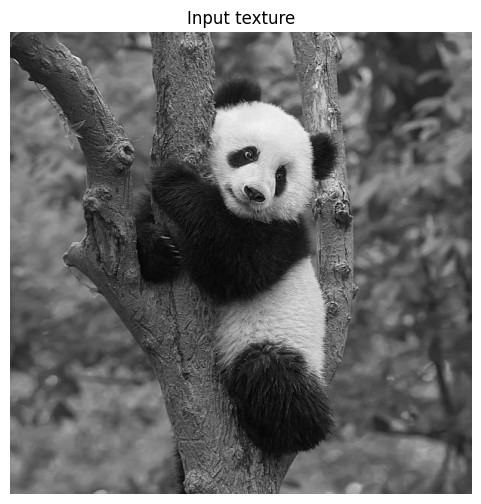

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, io, img_as_ubyte
from skimage.feature import graycomatrix, graycoprops

# Load your image
image = io.imread('images/1.jpg')
image = color.rgb2gray(image)
image = img_as_ubyte(image)

# Quantize intensity levels
levels = 8
bins = np.linspace(0, 256, levels+1).astype(int)
quant = np.digitize(image, bins) - 1
quant[quant == levels] = levels-1

# Compute GLCM
distances = [1]
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
# quant: your quantized grayscale image.
# distances: pixel offset distance (here 1 pixel away).
# angles: the direction between pixels:
# 0 → horizontal (right)
# π/4 → diagonal (top-right)
# π/2 → vertical (up)
# 3π/4 → diagonal (top-left)
# levels: number of gray levels (8).
# symmetric=True: makes GLCM symmetric, counting both (i,j) and (j,i) pairs.
# normed=True: normalizes so all values sum to 1 → now represent probabilities instead of counts.
glcm = graycomatrix(quant, distances=distances, angles=angles, levels=levels, symmetric=True, normed=True)

props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
results = {p: graycoprops(glcm, p) for p in props}

print("GLCM properties (rows = distance index, cols = angle index):")
for p in props:
    print(f"{p}:\n{results[p]}\n")

plt.figure(figsize=(6,6))
plt.imshow(image, cmap='gray')
plt.title('Input texture')
plt.axis('off')
plt.show()


## Gabor Filter — Texture & Frequency Selective Filter

**Idea:** Gabor filters are sinusoidal plane waves modulated by a Gaussian envelope. They are tuned to specific frequencies and orientations, making them excellent for texture and edge analysis.

**Usage:** Convolve image with Gabor kernels of different scales and orientations, use filter responses as features for retrieval or classification.

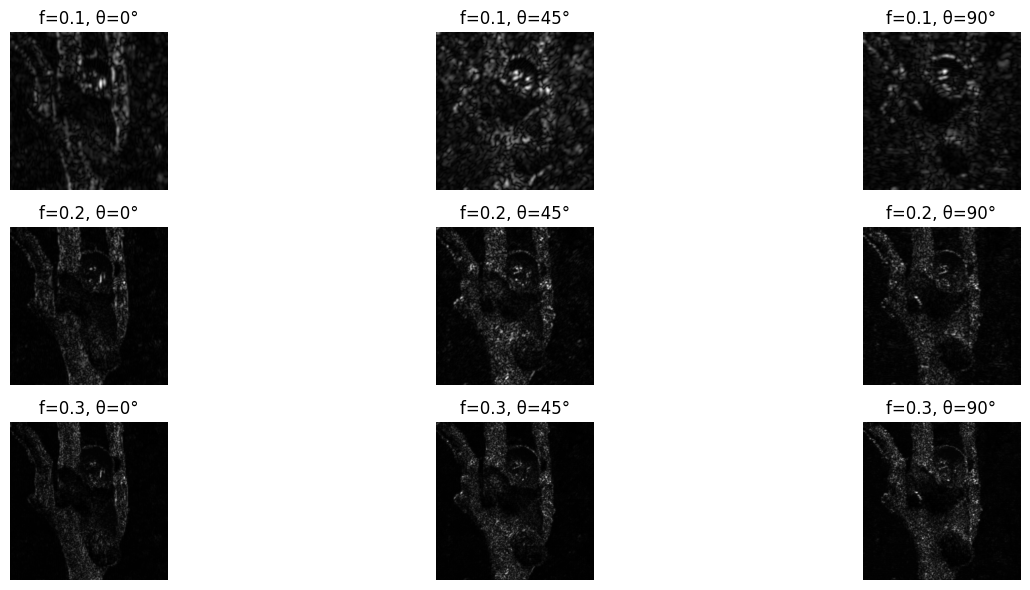

In [ ]:
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.filters import gabor
import matplotlib.pyplot as plt
import numpy as np

img = imread('images/1.jpg')
gray_img = rgb2gray(img)

frequencies = [0.1, 0.2, 0.3]
# θ = 0° → detects vertical features
# θ = 45° → detects diagonal features 
# θ = 90° → detects horizontal 
thetas_deg = [0, 45, 90]
thetas = np.deg2rad(thetas_deg)   # convert to radians
responses = []
i = 1

plt.figure(figsize=(15, 6))
for f in frequencies:
    for t in thetas:
        real, imag = gabor(gray_img, frequency=f, theta=t)
        mag = np.sqrt(real**2 + imag**2)   # recommended: use magnitude
        responses.append((f, t, mag))
        plt.subplot(len(frequencies), len(thetas), i)
        plt.imshow(mag, cmap='gray')
        plt.title(f'f={f}, θ={int(np.rad2deg(t))}°')
        plt.axis('off')
        i += 1

plt.tight_layout()
plt.show()


## Local Binary Pattern (LBP)

**Idea:** For each pixel, compare its neighbors to the center pixel; encode the result as a binary number (pattern). LBP histogram across an image patch is a powerful, rotation-invariant texture descriptor.

**Parameters:** radius and number of points (neighbors).

/Users/hayamedhat/micromamba/lib/python3.9/site-packages/skimage/feature/texture.py:353: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


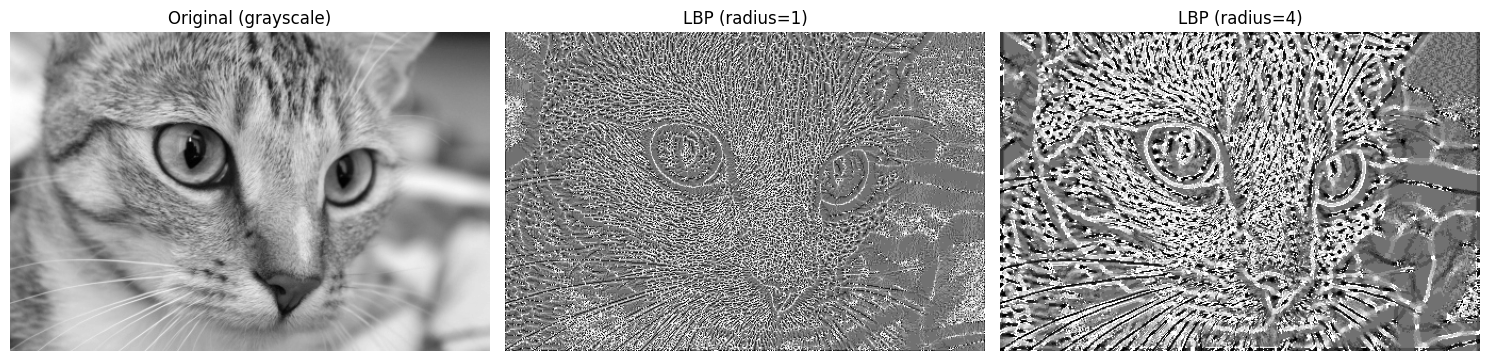

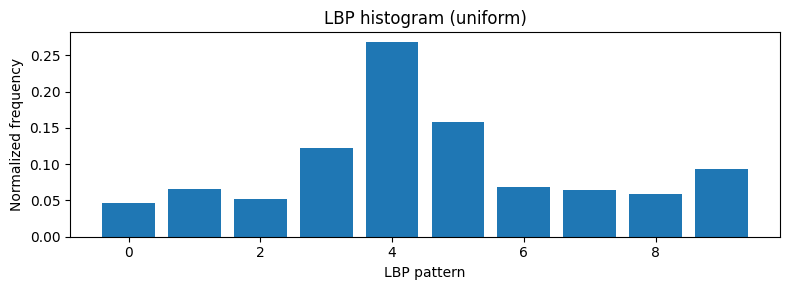

In [3]:
# LBP example using skimage
from skimage import data, color
from skimage.feature import local_binary_pattern
import numpy as np
import matplotlib.pyplot as plt

# Load image and convert to grayscale
img = color.rgb2gray(data.chelsea())  # cat image - has texture

# LBP parameters
radius = 1
n_points = 8 * radius

# Compute LBP with two different radii
lbp = local_binary_pattern(img, n_points, radius, method='uniform')
lbp2 = local_binary_pattern(img, n_points, 4, method='uniform')

# Build histogram of patterns
n_bins = int(lbp.max() + 1)
hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)

# Plot all side by side
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original (grayscale)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(lbp, cmap='gray')
plt.title("LBP (radius=1)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(lbp2, cmap='gray')
plt.title("LBP (radius=4)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Plot the histogram below
plt.figure(figsize=(8, 3))
plt.bar(range(n_bins), hist)
plt.title('LBP histogram (uniform)')
plt.xlabel('LBP pattern')
plt.ylabel('Normalized frequency')
plt.tight_layout()
plt.show()

## Chain Code — Structured Contour Descriptor

**Idea:** Represent the contour as a sequence of direction codes (e.g., 8-connectivity directions 0..7). Useful as a compact representation of boundary and for matching after normalization (rotation/scale).

**We will implement a simple chain-code extractor for a single contour. Note:** Advanced variants add differential chain codes, normalization, and Fourier descriptors.

Chain code (first 60 elements): [7, 0, 7, 6, 6, 7, 7, 6, 5, 3, 3, 5, 5, 5, 6, 6, 5, 4, 4, 4, 4, 5, 7, 0, 0, 0, 7, 7, 1, 1, 0, 0, 7, 5, 4, 4, 5, 7, 7, 6, 6, 6, 5, 5, 6, 7, 7, 5, 3, 3, 4, 5, 5, 4, 5, 6, 6, 6, 6, 6]


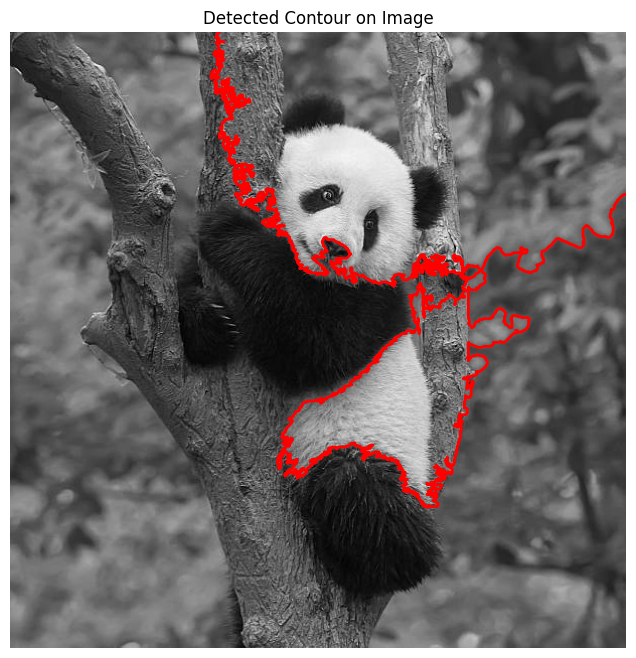

In [16]:
# Simple chain code extraction from a binary contour
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.measure import find_contours

# Read the image and convert to grayscale
img = imread('images/1.jpg')
gray = rgb2gray(img)

# Apply Otsu thresholding optimal threshold value that best separates dark and light
th = threshold_otsu(gray)
#Pixels darker than the threshold → True (object)
bw = gray < th

# Find contours
contours = find_contours(bw, 0.8)

# Pick the largest contour
contour = max(contours, key=lambda x: x.shape[0])

# Quantize directions between successive contour points into 8 directions
dirs = []
dvecs = np.array([[1,0],[1,-1],[0,-1],[-1,-1],[-1,0],[-1,1],[0,1],[1,1]])  # 8-connectivity

for i in range(len(contour) - 1):
    v = contour[i+1] - contour[i]
    #Computes the angle (in radians) of that movement direction between two consecutive contour points.
    ang = np.arctan2(v[0], v[1])  # row-major (y,x)
    sector = int(np.round(((ang + np.pi) / (2*np.pi)) * 8)) % 8
    dirs.append(sector)

print("Chain code (first 60 elements):", dirs[:60])
plt.figure(figsize=(8,8))
plt.imshow(gray, cmap='gray')
plt.plot(contour[:,1], contour[:,0], linewidth=2, color='red')
plt.title('Detected Contour on Image')
plt.axis('off')
plt.show()



## Region-based Descriptor — Global (Area)

**Area:** number of pixels inside the region. One of the simplest but effective global descriptors used alongside others.

This script creates three synthetic binary images (filled disks of three radii), computes each disk’s area (pixel count) using regionprops, then does a simple “toy retrieval” by finding which shape has area closest to a query area.

In [6]:
# Area extraction and a toy retrieval example
import numpy as np
from skimage.draw import disk, rectangle
from skimage.measure import label, regionprops

# create three binary shapes of different areas
imgs = []
areas = []
for i, r in enumerate([20, 35, 60]):
    im = np.zeros((120,120), dtype=np.uint8)
    rr, cc = disk((60,60), r)
    im[rr,cc] = 1
    imgs.append(im)
    lbl = label(im)
    rp = regionprops(lbl)[0]
    areas.append(rp.area)

print("Areas:", areas)

# toy retrieval: find shape most similar in area to query (area distance)
query_area = areas[1]
dists = [abs(a - query_area) for a in areas]
print("Distances to query area:", dists)

Areas: [1245.0, 3841.0, 11277.0]
Distances to query area: [2596.0, 0.0, 7436.0]


## Distance Measures — Euclidean, Cosine, Manhattan, Chebyshev

**Use:** Compare feature vectors (texture histograms, shape descriptors) using different distance metrics depending on sensitivity to magnitude, orientation, or outliers.

We'll implement small functions and demonstrate example comparisons.

In [7]:
# Distance measures implementations
import numpy as np

def euclidean(a,b): return np.linalg.norm(a-b)
def cosine_sim(a,b): 
    denom = np.linalg.norm(a)*np.linalg.norm(b)
    return (np.dot(a,b)/denom) if denom!=0 else 0.0
def manhattan(a,b): return np.sum(np.abs(a-b))
def chebyshev(a,b): return np.max(np.abs(a-b))

a = np.array([1.0,2.0,3.0])
b = np.array([2.0,2.0,4.0])
print("Euclidean:", euclidean(a,b))
print("Cosine similarity:", cosine_sim(a,b))
print("Manhattan:", manhattan(a,b))
print("Chebyshev:", chebyshev(a,b))

Euclidean: 1.4142135623730951
Cosine similarity: 0.9819805060619657
Manhattan: 2.0
Chebyshev: 1.0


## Search Complexity Reduction — PCA & K-means

**PCA:** Reduce dimensionality of feature vectors while preserving variance — speeds up comparisons and reduces noise.  
**K-means:** Cluster features (e.g., visual words) to index images; during retrieval search only nearest clusters.

We'll show PCA for dimensionality reduction and K-means to cluster synthetic feature vectors.

In [ ]:
# PCA and KMeans example
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# synthetic high-dim features (100 images, 128-d descriptors)
np.random.seed(0)
#(100 × 128) matrix called features.
features = np.random.randn(100,128)
#means we only keep 16 dimensions instead of 128
pca = PCA(n_components=16)
reduced = pca.fit_transform(features)
print("Original shape:", features.shape, "Reduced shape:", reduced.shape)
# KMeans on reduced features
kmeans = KMeans(n_clusters=8, random_state=0)
labels = kmeans.fit_predict(reduced)
print("KMeans labels (first 20):", labels[:20])

Original shape: (100, 128) Reduced shape: (100, 16)
KMeans labels (first 20): [1 0 6 6 4 6 6 6 0 1 6 2 5 1 0 0 4 0 1 1]


## Bilateral Filter — Edge-preserving Smoothing

**Idea:** Smooth noise while preserving edges by combining spatial and intensity kernels. Good for denoising while keeping edges intact.

We'll show skimage's bilateral/denoise_bilateral or fallback to OpenCV if available.

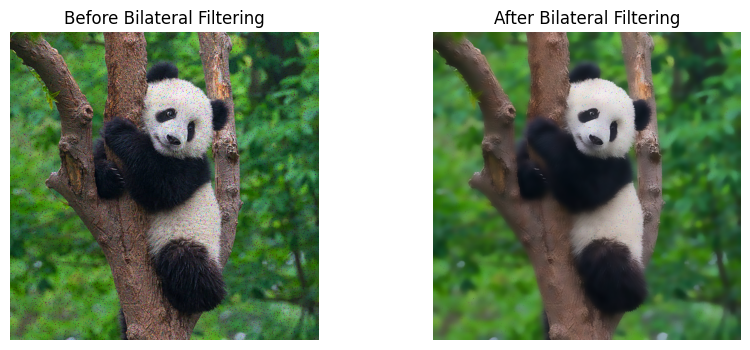

In [10]:
# Bilateral Filtering with Correct Colors
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.io import imread

# Read image (skimage loads in RGB)
img = imread("images/1.jpg")

img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
rng = np.random.RandomState(2)

noisy = img_bgr.copy()
prob = 0.03 
mask_sp = rng.rand(*img.shape) < prob
noisy[mask_sp] = rng.choice([0, 1], size=mask_sp.sum())  
# Apply bilateral filtering to remove noise while preserving edges.
# Parameters: d=16 (neighborhood diameter), sigmaColor=100 (color similarity threshold),
# sigmaSpace=100 (spatial distance influence) — higher values increase smoothing but keep edges sharp.
bilateral = cv2.bilateralFilter(noisy, 16, 100, 100)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB))
plt.title("Before Bilateral Filtering")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB))
plt.title("After Bilateral Filtering")
plt.axis('off')
plt.show()

## Adaptive Median Filter — Salt-and-Pepper Noise Removal

**Idea:** For each pixel, consider a window that grows until the median is a valid non-noisy value; replace center if it's noisy. Good for impulse noise (salt-and-pepper).

We'll provide a simple implementation and demo.

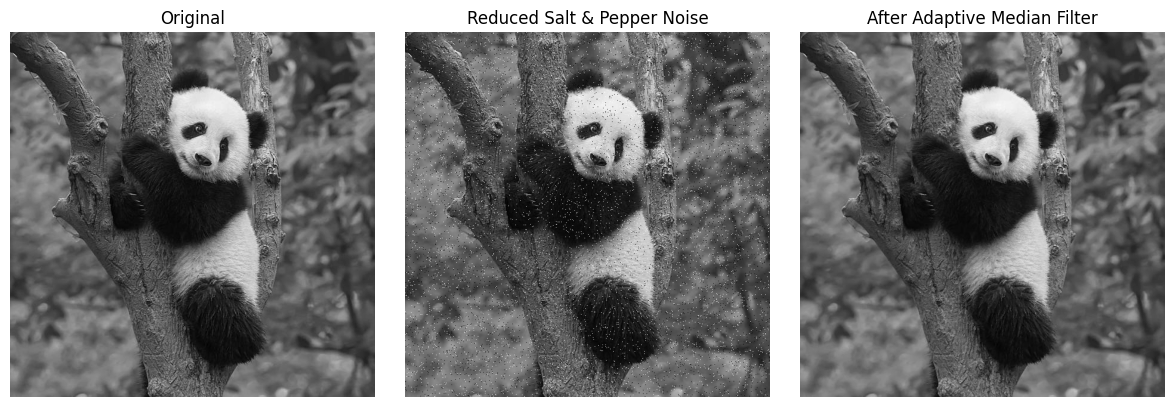

In [11]:
# Adaptive median filter implementation (simple)
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2gray

# Load and preprocess image
img = imread("images/1.jpg")
img = rgb2gray(img)
img = img.astype(float)

# Create salt-and-pepper noisy image (reduced noise)
rng = np.random.RandomState(2)
noisy = img.copy()
prob = 0.03 
mask_sp = rng.rand(*img.shape) < prob
noisy[mask_sp] = rng.choice([0, 1], size=mask_sp.sum())  # using 0 and 1 since img is float

def adaptive_median(im, max_size=7):
    out = im.copy()
    h, w = im.shape
    for i in range(h):
        for j in range(w):
            k = 3
            while k <= max_size:
                half = k // 2
                r0, r1 = max(0, i - half), min(h, i + half + 1)
                c0, c1 = max(0, j - half), min(w, j + half + 1)
                window = im[r0:r1, c0:c1].flatten()
                z_min = window.min()
                z_max = window.max()
                z_med = np.median(window)
                z_xy = im[i, j]
                A1 = z_med - z_min
                A2 = z_med - z_max
                if A1 > 0 and A2 < 0:
                    B1 = z_xy - z_min
                    B2 = z_xy - z_max
                    if B1 > 0 and B2 < 0:
                        out[i, j] = z_xy
                    else:
                        out[i, j] = z_med
                    break
                else:
                    k += 2
            if k > max_size:
                out[i, j] = z_med
    return out

filtered = adaptive_median(noisy, max_size=7)

# Visualization
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noisy, cmap='gray')
plt.title('Reduced Salt & Pepper Noise')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(filtered, cmap='gray')
plt.title('After Adaptive Median Filter')
plt.axis('off')

plt.tight_layout()
plt.show()